In [1]:
import requests
import pandas as pd
from typing import Final
from blocksnet.enums import LandUse


## Пример загрузки потенциала проекта из бд

In [2]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values", verify=False
)
if scenario_indicators_response.status_code != 200:
    raise Exception("Ошибка при получении индикаторов по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

LAND_USE_RULES: Final[dict[str, LandUse]] = {
    "Потенциал развития жилой застройки": LandUse.RESIDENTIAL,
    "Потенциал развития застройки общественно-деловой зоны": LandUse.BUSINESS,
    "Потенциал развития застройки рекреационной зоны": LandUse.RECREATION,
    "Потенциал развития застройки зоны специального назначения": LandUse.SPECIAL,
    "Потенциал развития застройки промышленной зоны": LandUse.INDUSTRIAL,
    "Потенциал развития застройки сельскохозяйственной зоны": LandUse.AGRICULTURE,
    "Потенциал развития застройки транспортной зоны": LandUse.TRANSPORT,
}

records: list[dict[str, object]] = []
for indicator_name, land_use in LAND_USE_RULES.items():
    potential = indicator_attributes.get(indicator_name)
    if potential is None:
        continue
    records.append({
        'land_use': land_use,
        'potential': potential,
    })

base_df = pd.DataFrame(records).reset_index(drop=True)
base_df.to_csv("./data/land_use_potentials.csv", index=False)

base_df

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'urban-api.idu.kanootoko.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,land_use,potential
0,LandUse.BUSINESS,2.0
1,LandUse.RECREATION,4.0
2,LandUse.SPECIAL,4.0
3,LandUse.INDUSTRIAL,4.0
4,LandUse.AGRICULTURE,3.0
5,LandUse.TRANSPORT,4.0


In [3]:
from urbanomy.methods.investment_potential import prepare_investment_input
scenario_blocks = pd.read_pickle('./data/blocks_with_price_test.pickle').to_crs(32636)
scenario_blocks = scenario_blocks.loc[scenario_blocks['is_scn'] == True].copy()

potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = scenario_blocks,
    project_potential = potential_df,
)

investment_input.head()


2025-10-28 19:11:13.751 | WARNING  | urbanomy.utils.investment_input:_prepare_with_base:348 - prepare_investment_input: у 3 из 70 кварталов нет land-use после нормализации; они остаются в наборе и будут обработаны на следующем этапе.


,land_use,price_pred,price_pred_before,site_area,living_area,non_living_area,build_floor_area,share,ip_value
0,LandUse.AGRICULTURE,3.132176e+08,1.040179e+08,202399.732193,0.000000,12550.410318,12550.410318,0.918180,3.0
1,LandUse.BUSINESS,3.488025e+08,1.035707e+08,201529.493481,0.000000,40777.536145,40777.536145,0.938081,2.0
2,LandUse.TRANSPORT,2.232646e+08,8.462455e+07,164663.859830,0.000000,24985.649917,24985.649917,0.891381,4.0
3,LandUse.RESIDENTIAL,7.195687e+08,8.303549e+07,161571.832511,29356.900162,43211.792478,72568.692640,0.934862,0.0
4,None,5.723364e+04,3.494857e+03,16.489152,0.000000,1.306345,1.306345,1.000000,0.0


## Инвевстиционная привлекательность

In [11]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 110_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}




In [12]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary


2025-10-28 19:11:50.722 | WARNING  | urbanomy.methods.investment_potential.investment_metrics:calculate_investment_metrics:556 - calculate_investment_metrics: 3 из 70 кварталов без land-use; пропускаем их в расчётах, но оставляем в итоговом отчёте.


Project totals:
 • Land area:          5,759,857.12
 • Built area:         1,426,481.21
 • Land cost:          4,034,271,949.65
 • Construction cost:  54,162,061,333.49
 • Investment need:    58,196,333,283.14
 • Spatial potential:  3.13
 • Project NPV:        10,640,388,483.88
 • Project IRR:        0.23
 • Project ROI:        7.28
 • Project PP (yrs):   9.34
 • Project EI:         70.07
 • Project INV score:  73.48


,land_use,land_area,land_purchase_price,built_area,land_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.AGRICULTURE,202399.73,1.040179e+08,12550.41,1.040179e+08,3.137603e+08,4.177781e+08,-1.122208e+08,0.12,4.11,NaN,0.00,3.0,31.07
1,LandUse.BUSINESS,201529.49,1.035707e+08,40777.54,1.035707e+08,2.242764e+09,2.346335e+09,7.518585e+08,0.25,13.79,9.81,77.32,2.0,66.00
2,LandUse.TRANSPORT,164663.86,8.462455e+07,24985.65,8.462455e+07,4.497417e+08,5.343663e+08,1.437464e+08,0.23,9.44,10.32,52.52,4.0,72.19
3,LandUse.RESIDENTIAL,161571.83,8.303549e+07,72568.69,8.303549e+07,3.265591e+09,3.348627e+09,1.188528e+09,0.32,4.81,4.96,100.00,0.0,58.57
4,None,NaN,3.494860e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,LandUse.BUSINESS,606.98,1.453714e+06,203.64,1.453714e+06,1.120008e+07,1.265379e+07,3.737800e+06,0.24,11.64,10.07,25.48,2.0,35.64
66,LandUse.AGRICULTURE,2.67,4.800058e+04,NaN,4.800058e+04,NaN,4.800058e+04,-4.454754e+04,0.09,2.90,NaN,0.00,3.0,31.07
67,LandUse.TRANSPORT,4307.66,2.213805e+06,688.58,2.213805e+06,1.239437e+07,1.460817e+07,4.467064e+06,0.24,9.87,9.88,25.64,4.0,56.45
68,LandUse.BUSINESS,61.63,2.220956e+04,13.49,2.220956e+04,7.417990e+05,7.640086e+05,3.216327e+05,0.26,15.79,9.03,35.28,2.0,41.38


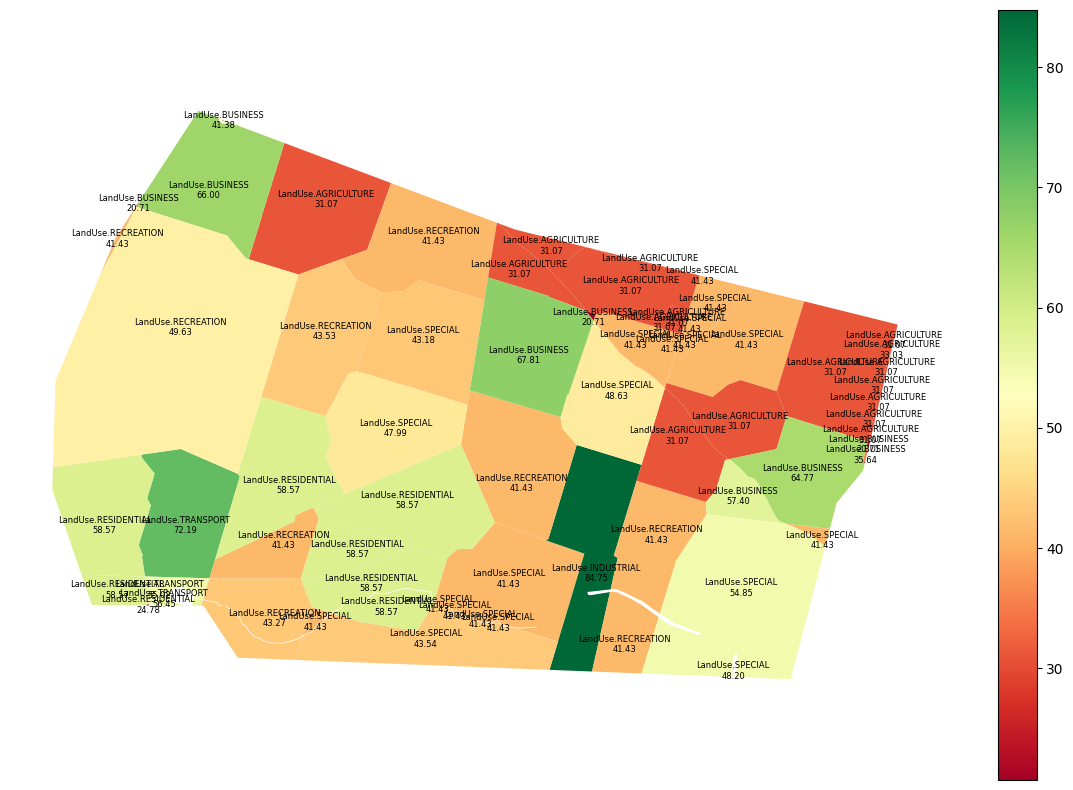

In [13]:
scn = scenario_blocks[['geometry']].join(summary)
column = 'INV'

ax = scn.plot(column=column, cmap='RdYlGn', legend=True, figsize=(15, 10))
for _, row in scn.dropna(subset=[column]).iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(
        x,
        y,
        f"{row.land_use}\n{row[column]:.2f}",
        ha="center",
        va="center",
        fontsize=6,
        color="black",
    )

ax.set_axis_off()

In [7]:
scn.to_file('./data/blocks_investment.geojson', driver='GeoJSON')